1. Create API call to extract gov data
Link to Austender Website: https://www.tenders.gov.au/Reports/CnPublishedForm


Website to read Json Format: https://jsonformatter.curiousconcept.com/

If json contains "next" under links. then this means the returned data from the API is not compelte. Another call needs to be made to the url in the next section to return the additional data, until there is no next section. Use this as a criteria to loop through and apply the function. 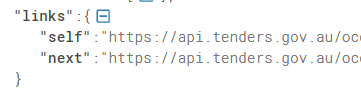

API Reference Data: https://github.com/austender/austender-ocds-api/tree/master

In [1]:
def read_austender_data(start,end):
    import requests
    import json

    start_date = start
    end_date = end

    url = f'https://api.tenders.gov.au/ocds/findByDates/contractPublished/{start_date}/{end_date}'

    response = requests.get(url)
    data = response.json()
    return data



In [2]:
def read_more_austender_data(url):
    import requests
    import json

    response = requests.get(url)
    data = response.json()
    return data

In [3]:
import pandas as pd

def pandas_data_frame(data_list):
    '''Create a flat file for the dataframe'''


    
    rows = []

    for page in data_list:
        for release in page.get('releases',[]):

            ocid = release.get('ocid')
            tender = release.get('tender',{})

            procurement_method = tender.get('procurementMethod')

            # Parties (supplier + procuring entity)
            parties = release.get('parties',[])

            # Awards (supplier info lives here too)
            awards = release.get('awards',[])

            # Contracts (value, UNSPSC, dates)
            contracts = release.get('contracts',[])

            for contract in contracts:
                contract_id = contract.get('id')
                contract_title = contract.get('title')
                contract_description = contract.get('description')

                #Contract Amounts
                value = contract.get('value',{})
                amount = value.get('amount')
                currency = value.get('currency')

                #Periods
                period = contract.get('period',{})
                start_date = period.get('startDate')
                end_date = period.get('endDate')

                #UNSPSC classification
                unspsc = None
                items = contract.get('items',[])
                for item in items:
                    classification = item.get('classification',{})
                    unspsc = classification.get('id')
                    break
                 

                #government agencies default
                agency_name = None
            

                for p in parties:
                    roles = p.get('roles',[])
                    if 'procuringEntity' in roles:
                        agency_name = p.get('name')
                        break
                
                #Suppliers
                supplier_name = None
                locality = None
                region = None
                postal = None
                country = None

                if awards:
                    suppliers = awards[0].get('suppliers',[])
                    if suppliers:
                        supplier_name = suppliers[0].get('name')

                        for p in parties:
                            if p.get('name') == supplier_name:
                                address = p.get('address',{})
                                locality = address.get('locality')
                                region = address.get('region')
                                postal = address.get('postalCode')
                                country = address.get('countryName')
                                break


                rows.append({
                    'ocid':ocid,
                    'contract_id':contract_id,
                    'contract_title':contract_title,
                    'contract_description':contract_description,
                    'supplier_name':supplier_name,
                    'unspsc':unspsc,
                    'amount':amount,
                    'start_date':start_date,
                    'end_date':end_date,
                    'locality':locality,
                    'region':region,
                    'postal':postal,
                    'country':country,
                    'procurement_method':procurement_method,
                    'agency_name':agency_name
                    })


    df = pd.DataFrame(rows)
    df['amount'] = pd.to_numeric(df['amount'],errors='coerce')


    return df

In [4]:
#If there are only 1 link then 'links' don't appear in the json

pages = []

begin_period = '2026-06-01T00:00:00Z'
end_period = '2026-06-30T23:59:59Z'


current = read_austender_data(begin_period,end_period)

while True:
    pages.append(current)

    links = current.get('links',{})
    next_url = links.get('next')

    if not next_url:
        break

    current = read_more_austender_data(next_url)


In [5]:
austender_df = pandas_data_frame(pages)

In [6]:
austender_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6399 entries, 0 to 6398
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ocid                  6399 non-null   object 
 1   contract_id           6399 non-null   object 
 2   contract_title        6357 non-null   object 
 3   contract_description  6399 non-null   object 
 4   supplier_name         6399 non-null   object 
 5   unspsc                6399 non-null   object 
 6   amount                6399 non-null   float64
 7   start_date            6399 non-null   object 
 8   end_date              6399 non-null   object 
 9   locality              6399 non-null   object 
 10  region                6399 non-null   object 
 11  postal                6397 non-null   object 
 12  country               6399 non-null   object 
 13  procurement_method    6399 non-null   object 
 14  agency_name           6399 non-null   object 
dtypes: float64(1), object

In [8]:
austender_df

,ocid,contract_id,contract_title,contract_description,supplier_name,unspsc,amount,start_date,end_date,locality,region,postal,country,procurement_method,agency_name
0,prod-6dfbf08d05294b0887e113e32925fc02,CN4256195,AC3084,IT sourcing specialist (LH-06646-RVE),The Recruitment Hive Pty Ltd,80111600,235552.80,2026-06-29T14:00:00Z,2026-12-29T13:00:00Z,Queanbeyan,NSW,2620,AUSTRALIA,open,Australian Transaction Reports and Analysis Ce...
1,prod-b14d9d5c0c02465f8460af887ea49812,CN4256194,NABPurch000061547982,Ranger Services,DEPARTMENT OF BIODIVERSITY CONSERVATION AND AT...,72102900,14165.79,2026-06-23T14:00:00Z,2026-06-23T14:00:00Z,Kensington,WA,6151,AUSTRALIA,limited,Department of Defence
2,prod-0b785563a97d4c07b503dcac72d75361,CN4248997,90016319,Management Advisory Services,University of New South Wales,80100000,972566.33,2026-06-17T14:00:00Z,2029-06-29T14:00:00Z,Sydney,NSW,1466,AUSTRALIA,open,Department of Social Services
3,prod-e62bac0ce29d4f9b91ee69bede840dba,CN4255742,NACC_487,Software Licenses,CBIT Digital Forensics Services,43230000,359681.30,2026-06-30T14:00:00Z,2027-06-29T14:00:00Z,Canberra,ACT,2609,AUSTRALIA,open,National Anti-Corruption Commission
4,prod-f4c6980c828847f99172345437bb3a57,CN4256187,0041008419,Metal Detector,Icorp Security Services Pty Ltd,46151600,18700.00,2026-07-10T14:00:00Z,2026-07-23T14:00:00Z,Tullamarine,VIC,3043,Australia,limited,Attorney-General's Department
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6394,prod-7e5791f9ca674e01b6e239877eae79a9,CN4245709,AC3051,Analyst IT Service Desk (LH-06238-MTP),MTP Services Pty Ltd,80111600,80639.20,2026-06-07T14:00:00Z,2026-12-06T13:00:00Z,Fyshwick,ACT,2609,AUSTRALIA,open,Australian Transaction Reports and Analysis Ce...
6395,prod-ee43b1b92c884f5a9d61ee50799aaa63,CN4245706,SCO002923-0,Labour Hire,Hays Personnel Services (Aust) PL,80111600,178718.00,2026-05-31T14:00:00Z,2027-05-30T14:00:00Z,Sydney,NSW,2001,AUSTRALIA,open,Australian Financial Security Authority
6396,prod-1c749af511044586a7c73eb79289985c,CN4245707,SCO002888-0,Labour Hire,Hays Personnel Services (Aust) PL,80111600,178718.00,2026-05-31T14:00:00Z,2027-05-30T14:00:00Z,Sydney,NSW,2001,AUSTRALIA,open,Australian Financial Security Authority
6397,prod-2e253c4485f44c42bd4d3a90b16a9c2c,CN4245704,SCO002914-0,Introduction and Placement Services,TALENT INTERNATIONAL HOLDINGS PTY LTD,80111600,50000.00,2026-05-31T14:00:00Z,2027-03-30T13:00:00Z,Deakin,ACT,2600,AUSTRALIA,open,Australian Financial Security Authority


In [48]:
#Top 5 By Average Amount Spend per trender by Agency during the Period. 
#Also listing Total Amount

top5Agency_total_Spend = (austender_df.groupby(
    'agency_name',as_index=False
    ).agg(
        total_amount = ('amount','sum')
        ).sort_values('total_amount',ascending=False).head(5))

top5Agency_total_Spend['agency_name'] = (
    top5Agency_total_Spend['agency_name'].str.replace(' - ','\n')
)
top5Agency_total_Spend['agency_name'] = (
    top5Agency_total_Spend['agency_name'].str.replace('Department of ','')
)

top5Agency_Ave_spend = (austender_df.groupby(
    'agency_name',as_index=False
    ).agg(
        average_amount = ('amount','mean')
        ).sort_values('average_amount',ascending=False).head(5))

top5Agencies = (austender_df.groupby(
    'agency_name',as_index=False
    ).agg(
        num_of_contracts = ('contract_id','count')
        ).sort_values('num_of_contracts',ascending=False).head(5))

top_5Suppliers = (austender_df.groupby(
    'supplier_name',as_index=False
).agg(
    total_awarded = ('amount','sum'))
    .sort_values('total_awarded',ascending=False).head(5))
                  

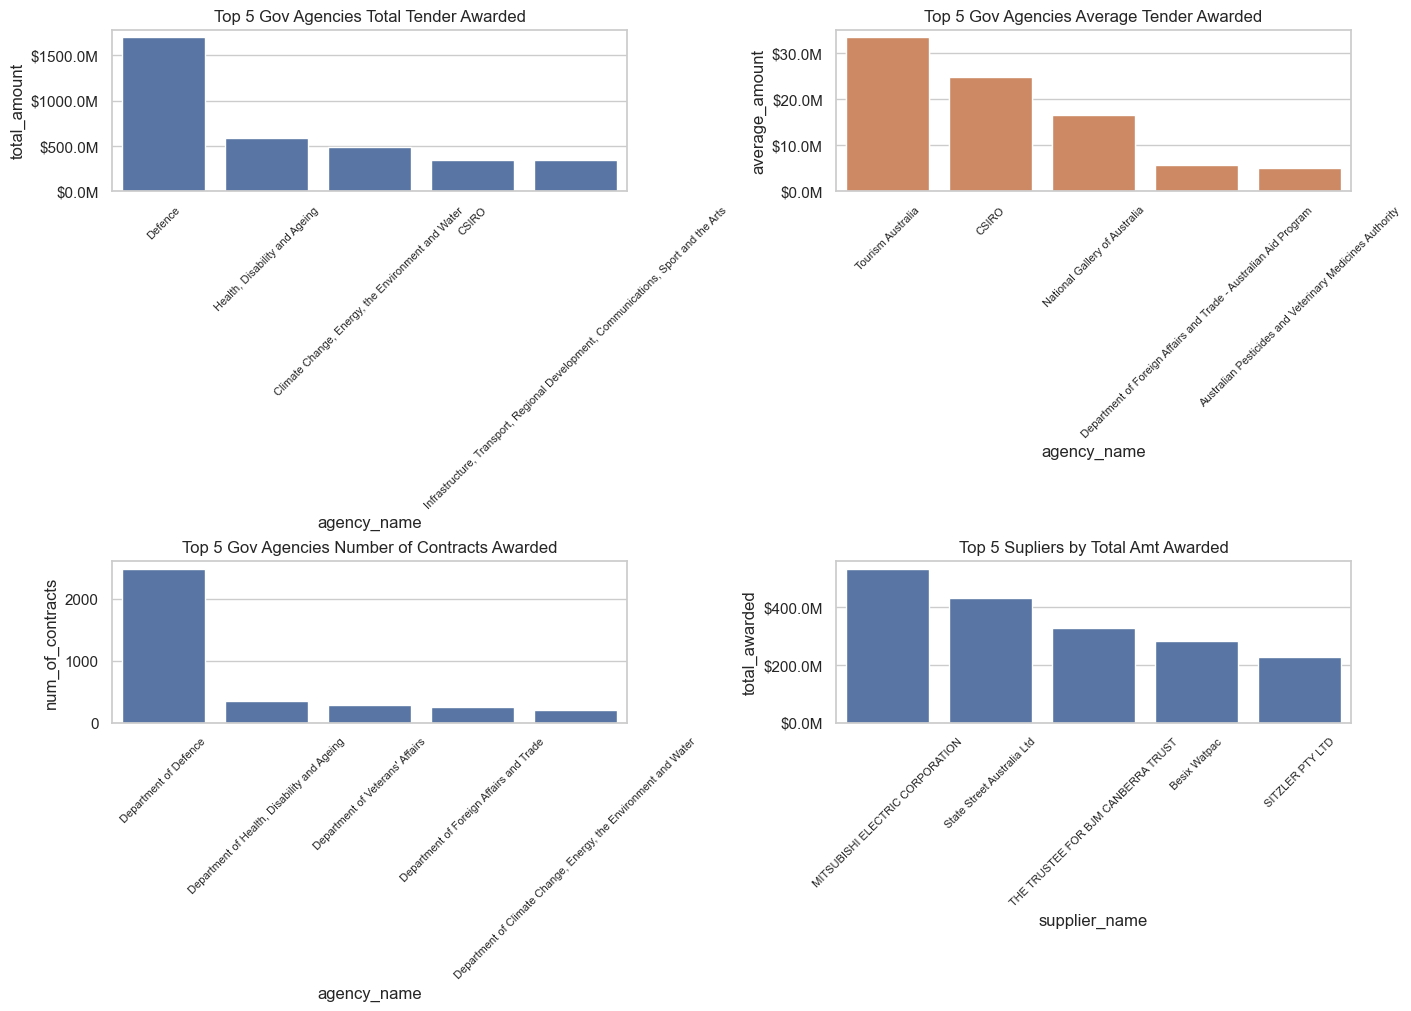

In [49]:
from networkx import constraint
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
sns.set_theme(style='whitegrid')

fig,axes = plt.subplots(2,2,figsize=(14,10),constrained_layout=True)
for ax in axes.ravel():
    ax.margins(x=0.01)

#Total Amount
sns.barplot(
    data = top5Agency_total_Spend,
    x='agency_name',
    y='total_amount',
    ax=axes[0,0]
)
axes[0,0].set_title('Top 5 Gov Agencies Total Tender Awarded')
axes[0,0].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,_ : f'${x/1_000_000:.1f}M')
)
axes[0,0].tick_params(axis='x',rotation=45)

#Average Spend
sns.barplot(data=top5Agency_Ave_spend,
            x='agency_name',
            y='average_amount',
            ax=axes[0,1])
axes[0,1].set_title('Top 5 Gov Agencies Average Tender Awarded')
axes[0,1].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,_ : f'${x/1_000_000:.1f}M')
)
axes[0,1].tick_params(axis='x',rotation=45)

#Top 5 Number of Contracts
sns.barplot(data=top5Agencies,
            x='agency_name',
            y='num_of_contracts',
            ax=axes[1,0])
axes[1,0].set_title('Top 5 Gov Agencies Number of Contracts Awarded')
axes[1,0].tick_params(axis='x',rotation=45)

#Average Spend
sns.barplot(data=top5Agency_Ave_spend,
            x='agency_name',
            y='average_amount',
            ax=axes[0,1])
axes[0,1].set_title('Top 5 Gov Agencies Average Tender Awarded')
axes[0,1].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,_ : f'${x/1_000_000:.1f}M')
)
axes[0,1].tick_params(axis='x',rotation=45)

#Top 5 Amt by Supplier
sns.barplot(data=top_5Suppliers,
            x='supplier_name',
            y='total_awarded',
            ax=axes[1,1])
axes[1,1].set_title('Top 5 Supliers by Total Amt Awarded')
axes[1,1].tick_params(axis='x',rotation=45)
axes[1,1].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,_ : f'${x/1_000_000:.1f}M'))

for ax in axes.ravel():
    ax.tick_params(axis='x',labelsize=8)

#plt.tight_layout()
plt.show()

C:\Users\shaun\AppData\Local\Temp\ipykernel_34576\2829971445.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


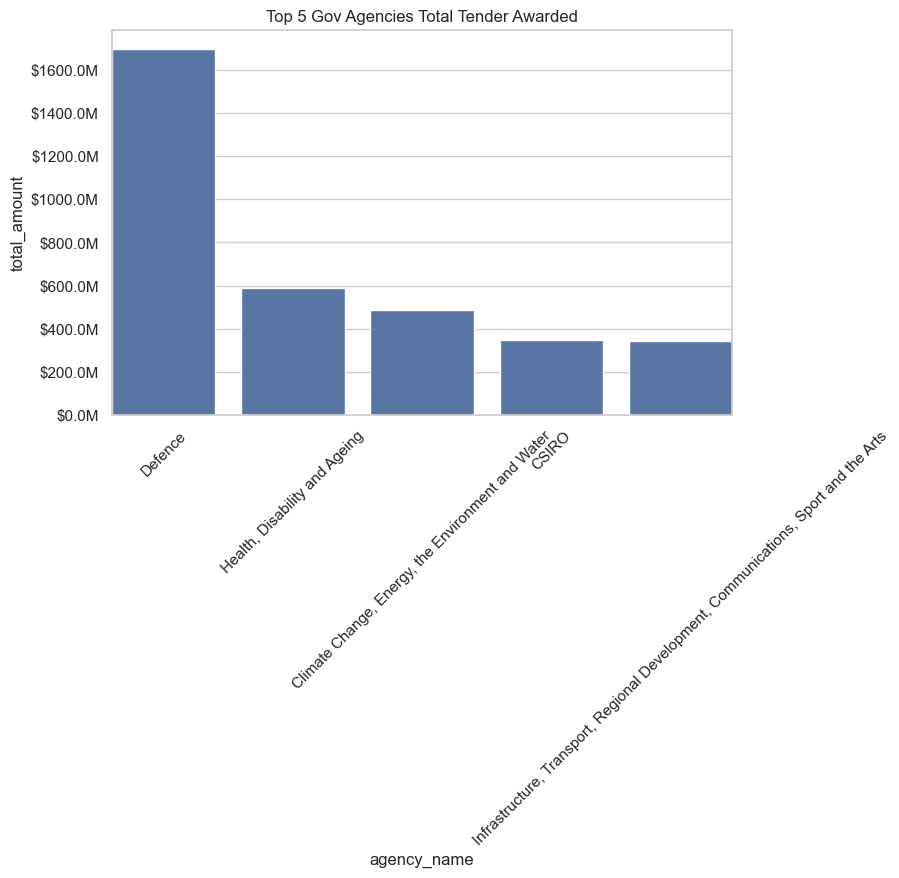

In [54]:
fig,ax = plt.subplots(figsize=(8,5))

sns.barplot(
    data = top5Agency_total_Spend,
    x='agency_name',
    y='total_amount',
    ax=ax
)


ax.set_title('Top 5 Gov Agencies Total Tender Awarded')

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,_ : f'${x/1_000_000:.1f}M')
)

ax.tick_params(axis='x',rotation=45)
ax.margins(x=0.01)

ax.set_xlim(-0.4, len(top5Agency_total_Spend)-0.6)

plt.tight_layout()
plt.show()